# Regresión Lineal Simple

### Vamos a predecir el salario de una persona en función de sus años de experiencia.


Modelo estadístico que relaciona una variable dependiente `y` con una independiente `x` mediante una línea recta.

### Fórmula

# y = mx + b + ε


| Símbolo | Significado |
|---------|-------------|
| **y** | Variable dependiente (predicción) |
| **x** | Variable independiente (predictor) |
| **m** | Pendiente (cambio en y por unidad de x) |
| **b** | Intercepto (valor de y cuando x = 0) |
| **ε** | Error/residuo (variabilidad no explicada) |

### Objetivo
🎯 Encontrar `m` y `b` que **minimicen la suma de errores al cuadrado** (método de mínimos cuadrados).

### Supuestos clave
- ✅ Linealidad entre x e y  
- ✅ Independencia de residuos  
- ✅ Homocedasticidad (varianza constante del error)  
- ✅ Normalidad de los residuos  

> 📌 **Nota**: El término `ε` captura todo lo que el modelo *no* puede explicar: ruido, variables omitidas o relaciones no lineales.

## 1. Importamos las librerías, lectura del datset y EDA

In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [90]:
# Leemos el dataset
df = pd.read_csv("Salary_dataset.csv", index_col = 0)
df.head(5)

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [91]:
# Extensión del dataset
df.shape

(30, 2)

In [92]:
# Nombre de las columnas
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [93]:
# Renombramos las columnas a español
df = df.rename(columns = {
   'YearsExperience': 'anios_experiencia',
    'Salary': 'salario'
})

In [94]:
# Miramos el dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   anios_experiencia  30 non-null     float64
 1   salario            30 non-null     float64
dtypes: float64(2)
memory usage: 720.0 bytes


In [95]:
# Valores nulos
df.isnull().sum()

anios_experiencia    0
salario              0
dtype: int64

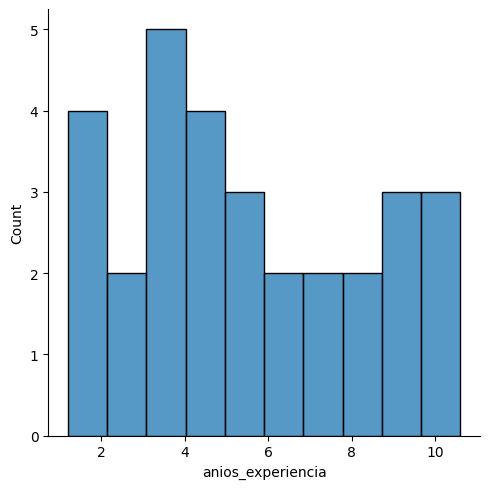

In [96]:
# Miramos la distribución de la variable anios_experiencia
sns.displot(df['anios_experiencia'], bins = 10)
plt.show()

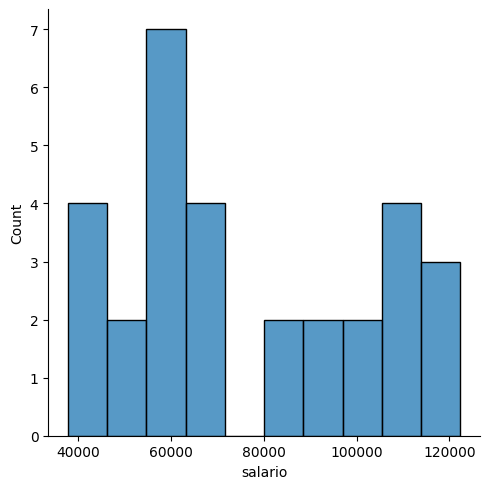

In [97]:
# Miramos la distribución de la variable anios_experiencia
sns.displot(df['salario'], bins = 10)
plt.show()

## 2. Correlación de Pearson

- El coeficiente de correlación de Pearson es una prueba que mide la relación estadística entre dos variables continuas.

- Mide la relación lineal entre dos variables cuantitativas, con valores entre -1 y +1.

**Interpretación**

- r = +1: correlación lineal positiva perfecta (ambas variables aumentan juntas).
- r = -1: correlación lineal negativa perfecta (una variable aumenta mientras la otra disminuye).
- r = 0: no hay relación lineal, aunque puede existir otro tipo de relación. 

Valores intermedios indican la fuerza y dirección de la relación: cuanto más cercano a ±1, más fuerte es la correlación.


<Axes: >

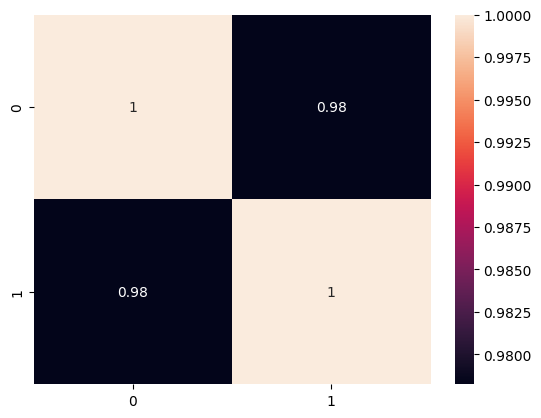

In [98]:
# Matriz de correlación de pearson
correlacion_matriz_salario = np.corrcoef(df['salario'], df['anios_experiencia'])
sns.heatmap(data =correlacion_matriz_salario, annot = True)

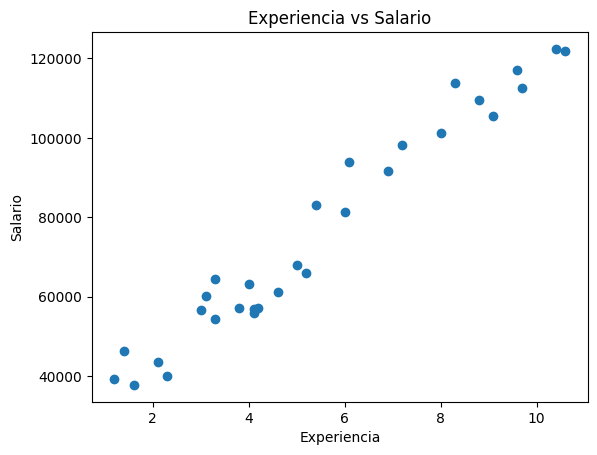

In [99]:
# Hacemos un diagrama de dispersión.
plt.scatter( df['anios_experiencia'],df['salario'])
plt.title("Experiencia vs Salario")
plt.xlabel("Experiencia")
plt.ylabel("Salario")
plt.show()

In [100]:
# Miramos la estadística descriptiva de los datos.
df.describe()

,anios_experiencia,salario
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


Una vez que heos visto que los datos tienen relación lineal, vamos a dividir el dataset en train y test.

## 3. Dividir el dataset entre Entrenamiento y Test

In [101]:
#pip install scikit-learn

In [102]:
# Separamos el dataset entre el target y las variables predictoras.
X_experiencia = df[["anios_experiencia"]]
y_salario = df["salario"]

In [103]:
#X_experiencia

In [104]:
# Dividimos el dataset: 80% para entrenamiento - 20% para prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_experiencia, y_salario, test_size = 0.2, random_state = 42)
print("X train = ", X_train.shape)
print("X test = ", X_test.shape)
print("y train = ", y_train.shape)
print("y test = ", y_test.shape)

X train =  (24, 1)
X test =  (6, 1)
y train =  (24,)
y test =  (6,)


## 4. Creamos el Modelo Lineal

In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [106]:
# Entrnamo el modelo
# X_train = X_train.values.reshape(-1, 1)
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [107]:
lin_model.predict(np.array([[1]]))

C:\Users\mmunoz\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([33804.0168025])

In [108]:
lin_model.predict(np.array([[10]]))

C:\Users\mmunoz\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([118618.35470978])

In [109]:
#X_test.shape

In [110]:
#X_text = X_test.values.reshape(-1,1)
#X_test.shape

## 4. Evaluación del modelo

## Fórmula del R² (Coeficiente de Determinación)

### Fórmula principal

# R² = 1 - (SS_res / SS_tot)


### Desglose de términos
| Símbolo | Fórmula | Significado |
|---------|---------|-------------|
| **SS_res** | `Σ(yᵢ - ŷᵢ)²` | Suma de cuadrados de los residuos (error no explicado) |
| **SS_tot** | `Σ(yᵢ - ȳ)²` | Suma total de cuadrados (variabilidad total de y) |
| **yᵢ** | - | Valor observado |
| **ŷᵢ** | - | Valor predicho por el modelo |
| **ȳ** | - | Media de los valores observados |

### Interpretación
> **R² = Proporción de la varianza de `y` explicada por el modelo**  
> Ejemplo: R² = 0.75 → El modelo explica el 75% de la variabilidad de los datos.

---

## ⚠️ ¿Es el R² lo "más importante"? → No necesariamente

Aunque el R² es **útil y popular**, **no debe ser la única métrica** que consideres:

| Limitación del R² | Por qué importa |
|-------------------|----------------|
| ❌ Siempre aumenta al agregar variables | Puede favorecer modelos sobreajustados |
| ❌ No mide causalidad | Correlación ≠ causa |
| ❌ Insensible a sesgos sistemáticos | Un modelo puede tener R² alto pero predecir mal en nuevos datos |
| ❌ No compara modelos con diferentes respuestas | Solo útil para comparar modelos sobre el mismo dataset |



### El R² (coeficiente de determinación) en una regresión lineal mide la proporción de la varianza de la variable dependiente que es explicada por el modelo. Su valor teórico oscila entre 0 y 1 (o 0% y 100%):

| Rango de R² | Interpretación | Contexto típico |
|-------------|---------------|-----------------|
| **0.00 - 0.25** | Muy baja capacidad explicativa | Modelos preliminares o sistemas altamente complejos |
| **0.25 - 0.50** | Baja a moderada | Ciencias sociales, biología, agricultura |
| **0.50 - 0.70** | Moderada a buena | Muchos campos aplicados; equilibrio común |
| **0.70 - 0.90** | Buena a muy buena | Ingeniería, ciencias físicas, modelos bien especificados |
| **0.90 - 1.00** | Excelente | Sistemas controlados; ⚠️ validar sobreajuste |
| **1.00** | Ajuste perfecto | Poco realista en datos reales; revisar fuga de datos |

### ✅ Métricas complementarias recomendadas

| Métrica | Cuándo usarla |
|---------|--------------|
| **R² ajustado** | Modelos con múltiples predictores (penaliza variables irrelevantes) |
| **RMSE / MAE** | Evaluar error de predicción en unidades originales de `y` |
| **Validación cruzada** | Medir capacidad de generalización en datos no vistos |
| **Análisis de residuos** | Verificar supuestos del modelo (normalidad, homocedasticidad) |
| **AIC / BIC** | Comparar modelos con diferente complejidad |

In [111]:
from sklearn.metrics import r2_score
#X_text = X_test.values.reshape(-1,1)
y_test_predict = lin_model.predict(X_test)    # Con los datos de X_test probamos el modelo
r2 = r2_score(y_test, y_test_predict)         # Comparamos los datos reales con los predichos
print("El desempeño del modelo en el conjunto de test es:")
print("--------------------------------------")
print("La puntuación de R2 es: {}".format(r2))

El desempeño del modelo en el conjunto de test es:
--------------------------------------
La puntuación de R2 es: 0.9024461774180498


## Vamos a ver los térmimnos de m y b de la recta: **y = mx + b**

In [112]:
print('Coeficiente: m =  ', lin_model.coef_)
print('Término independoente: b = ', lin_model.intercept_)

Coeficiente: m =   [9423.81532303]
Término independoente: b =  24380.20147947369


 # y = 9423.81532303x + 24380.20147947369

## Predicciones

Vamos a realizar las prediccciones con el modelo entrenado, ahora con todos los datos, es decir con toda la columna:

- ### df['anios_experiencia']

In [113]:
# df['anios_experiencia'].values.reshape(-1,1) --> este formato debemos ponerlo para que nos responda el modelo
predicted_data_salario = lin_model.predict(df['anios_experiencia'].values.reshape(-1,1))    
predicted_data_salario

C:\Users\mmunoz\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 35688.77986711,  37573.54293172,  39458.30599632,  44170.21365784,
        46054.97672244,  52651.64744857,  53594.02898087,  55478.79204548,
        55478.79204548,  60190.69970699,  62075.4627716 ,  63017.8443039 ,
        63017.8443039 ,  63960.2258362 ,  67729.75196542,  71499.27809463,
        73384.04115923,  75268.80422384,  80923.09341766,  81865.47494996,
        89404.52720839,  92231.6718053 ,  99770.72406372, 102597.86866063,
       107309.77632215, 110136.92091906, 114848.82858057, 115791.21011287,
       122387.880839  , 124272.6439036 ])

### Vamos a dibujar la linea, con la columna **df['anios_experiencia']** y la **predicted_data_salario** que son los datos predichos de toda la variable

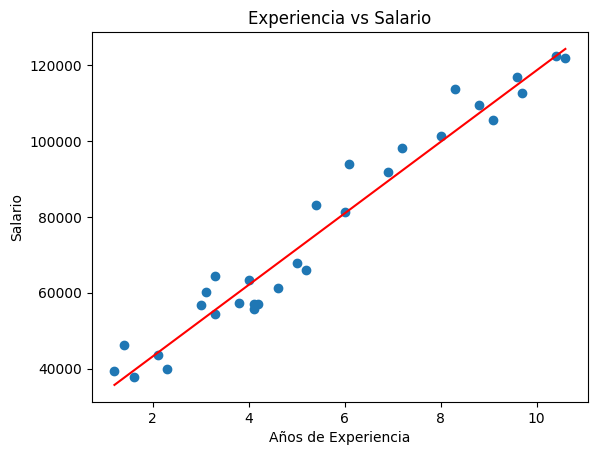

In [114]:
plt.scatter(df['anios_experiencia'], df['salario'])
plt.plot(df['anios_experiencia'], predicted_data_salario, color = 'red')
plt.title('Experiencia vs Salario')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario')
plt.show()

## Vamos a ver los valores reales y los predichos

In [115]:
df1 = pd.DataFrame({'Real':df['salario'], 'Predicción': predicted_data_salario})
df1

,Real,Predicción
0,39344.0,35688.779867
1,46206.0,37573.542932
2,37732.0,39458.305996
3,43526.0,44170.213658
4,39892.0,46054.976722
5,56643.0,52651.647449
6,60151.0,53594.028981
7,54446.0,55478.792045
8,64446.0,55478.792045
9,57190.0,60190.699707


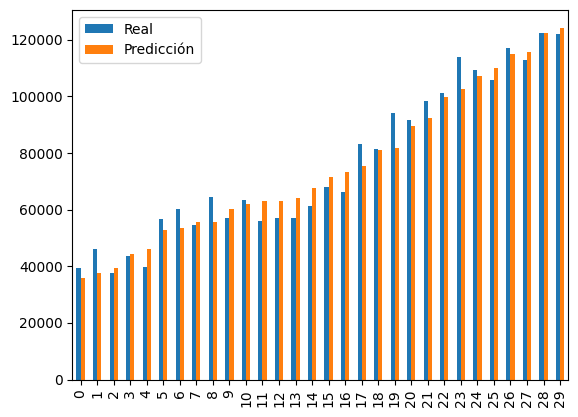

In [116]:
df1.head(30).plot(kind = 'bar')
plt.show()

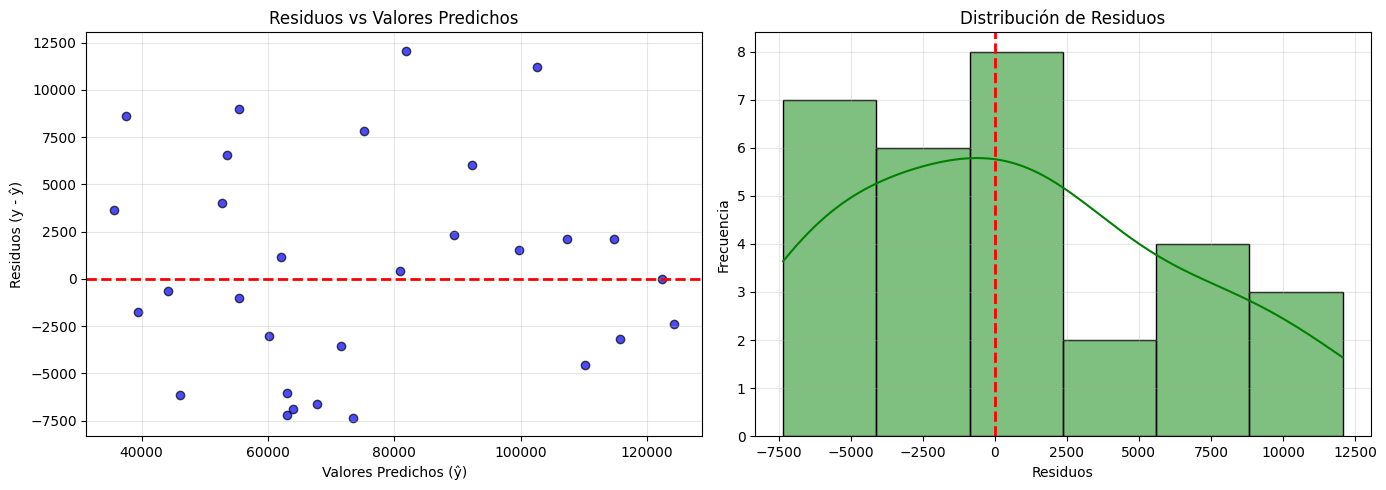

R²: 0.9564
RMSE: 5625.6394
Media de residuos: 609.5449


In [120]:
residuos = df['salario'] - predicted_data_salario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Residuos vs Valores Predichos
axes[0].scatter(predicted_data_salario, residuos, color='blue', alpha=0.7, edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valores Predichos (ŷ)')
axes[0].set_ylabel('Residuos (y - ŷ)')
axes[0].set_title('Residuos vs Valores Predichos')
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Distribución de Residuos (Histograma + KDE)
sns.histplot(residuos, kde=True, ax=axes[1], color='green', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuos')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Métricas del modelo
print(f"R²: {r2_score(df['salario'], predicted_data_salario):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(df['salario'], predicted_data_salario)):.4f}")
print(f"Media de residuos: {np.mean(residuos):.4f}")